In [1]:
!kaggle datasets download -d yasserh/wine-quality-dataset --unzip

Dataset URL: https://www.kaggle.com/datasets/yasserh/wine-quality-dataset
License(s): CC0-1.0
100%|███████████████████████████████████████| 21.5k/21.5k [00:00<00:00, 535kB/s]



In [2]:
import pandas as pd

df = pd.read_csv('WineQT.csv')
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


In [3]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
count,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000
mean,8.311111,0.531339,0.268364,2.532152,0.086933,15.615486,45.914698,0.996730,3.311015,0.657708,10.442111,5.657043,804.969379
std,1.747595,0.179633,0.196686,1.355917,0.047267,10.250486,32.782130,0.001925,0.156664,0.170399,1.082196,0.805824,463.997116
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000,0.000000
25%,7.100000,0.392500,0.090000,1.900000,0.070000,7.000000,21.000000,0.995570,3.205000,0.550000,9.500000,5.000000,411.000000
50%,7.900000,0.520000,0.250000,2.200000,0.079000,13.000000,37.000000,0.996680,3.310000,0.620000,10.200000,6.000000,794.000000
75%,9.100000,0.640000,0.420000,2.600000,0.090000,21.000000,61.000000,0.997845,3.400000,0.730000,11.100000,6.000000,1209.500000
max,15.900000,1.580000,1.000000,15.500000,0.611000,68.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000,1597.000000


In [4]:
df = df[['quality', 'alcohol','citric acid']]
df

,quality,alcohol,citric acid
0,5,9.4,0.00
1,5,9.8,0.00
2,5,9.8,0.04
3,6,9.8,0.56
4,5,9.4,0.00
...,...,...,...
1138,6,11.0,0.13
1139,6,9.5,0.08
1140,5,10.5,0.08
1141,6,11.2,0.10


In [5]:
df['quality'].unique()

array([5, 6, 7, 4, 8, 3])

Text(0.5, 1.0, 'Alcohol vs Citric Acid by Quality')

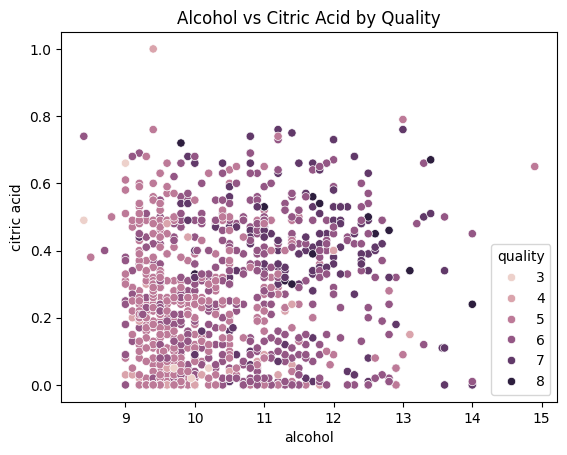

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns


sns.scatterplot(
    data=df,
    x='alcohol',
    y='citric acid',
    hue='quality'
)

plt.title('Alcohol vs Citric Acid by Quality')

<Axes: xlabel='citric acid', ylabel='Density'>

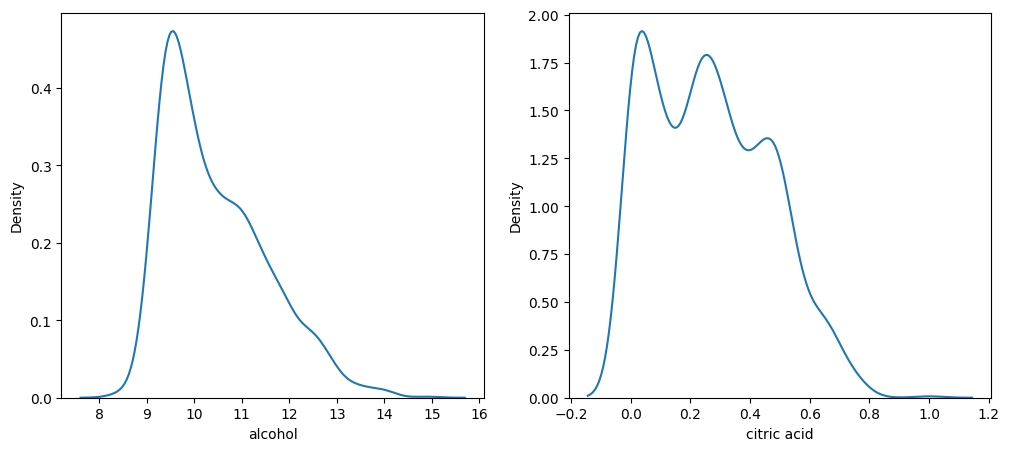

In [7]:
fig, axes = plt.subplots(1,2, figsize=(12, 5))

sns.kdeplot(df['alcohol'], ax=axes[0])
sns.kdeplot(df['citric acid'], ax=axes[1])



In [8]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    df.drop('quality', axis=1),
    df['quality'],
    test_size=0.3,
    random_state=0
)

df.shape

(1143, 3)

### Formula: `x' = (x - xmin) / (xmax - xmin)` using the training min and max.



- Why is Training Data Between [0,1] But Test Data May Not Be?

    - MinMaxScaler always produces values between 0 and 1

     - this is not true for test data because min 7 max were calculated from training only to not let the  data leak during evaulation accuracy.

In [9]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

scaler.fit(x_train)

scaled_x_train = scaler.transform(x_train)
scaled_x_test = scaler.transform(x_test)

scaled_x_train = pd.DataFrame(scaled_x_train, columns=x_train.columns)
scaled_x_test = pd.DataFrame(scaled_x_test, columns=x_test.columns)

In [10]:
df.describe()

,quality,alcohol,citric acid
count,1143.000000,1143.000000,1143.000000
mean,5.657043,10.442111,0.268364
std,0.805824,1.082196,0.196686
min,3.000000,8.400000,0.000000
25%,5.000000,9.500000,0.090000
50%,6.000000,10.200000,0.250000
75%,6.000000,11.100000,0.420000
max,8.000000,14.900000,1.000000


In [11]:
import numpy as np

np.round(scaled_x_train.describe(), 2)

,alcohol,citric acid
count,800.00,800.00
mean,0.32,0.33
std,0.17,0.25
min,0.00,0.00
25%,0.17,0.10
50%,0.28,0.30
75%,0.43,0.53
max,1.00,1.00


- The reason the test set does not necessarily have a minimum value of 0 and a maximum value of 1 after Min-Max scaling is that the scaler is fitted only on the training data. 
- When we call `scaler.fit(x_train)`, the scaler learns the minimum and maximum values present in the training set and stores them. Later, when `transform()` is applied to both the training and test sets, the same training-set minimum and maximum values are used for scaling. 
- As a result, the training data is guaranteed to be scaled approximately into the range [0, 1], but the test data is not. If a test observation contains a value larger than the training maximum, its scaled value will be greater than 1. Similarly, if it contains a value smaller than the training minimum, its scaled value will be less than 0. 
- This behavior is expected and ensures that no information from the test set leaks into the training process.


In [12]:
import numpy as np

np.round(scaled_x_test.describe(), 2)

,alcohol,citric acid
count,343.00,343.00
mean,0.30,0.36
std,0.16,0.25
min,0.02,0.00
25%,0.17,0.14
50%,0.26,0.33
75%,0.40,0.54
max,0.79,1.27


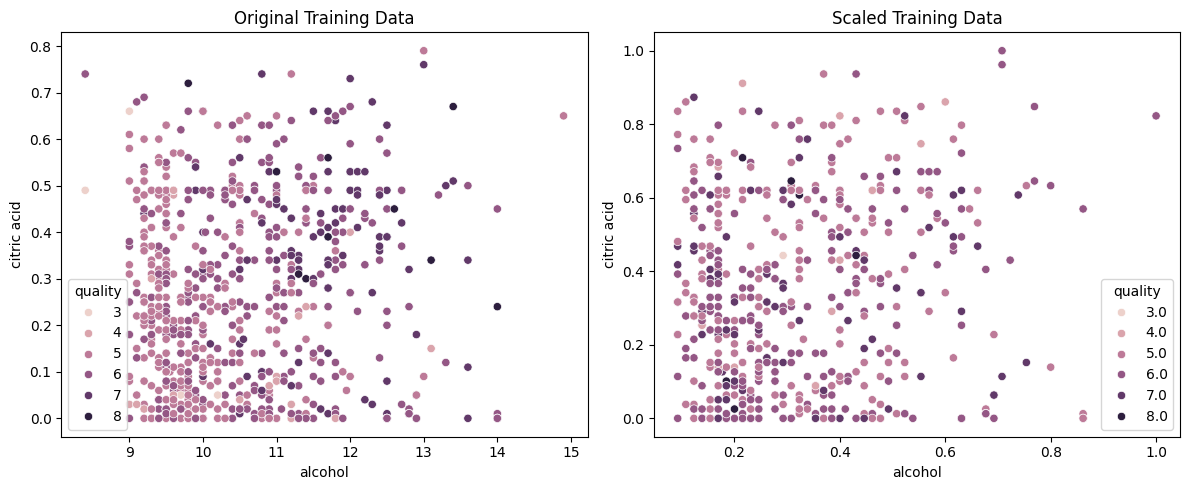

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))


sns.scatterplot(data=x_train, x='alcohol', y='citric acid', hue=y_train, ax=axes[0])
sns.scatterplot(data=scaled_x_train, x='alcohol', y='citric acid', hue=y_train, ax=axes[1])

axes[1].set_title('Scaled Training Data')
axes[0].set_title('Original Training Data')
plt.tight_layout()
plt.show()

- I check that stracture and hue is changed before and after min-max scaling, Its beacuse the  dat points are stretched or srinks into the range of [-1,1].
- so, even though the data points seems to be at the same location with different hue, they are not the same data points. because the hue is not scaled and hance it`ll preserve the color. 
- to prove this I have checked the relkationship(corr.) between the columns before and after scaling.

In [14]:
print(x_train[['alcohol','citric acid']].corr())

print(scaled_x_train[['alcohol','citric acid']].corr())

             alcohol  citric acid
alcohol      1.00000      0.10982
citric acid  0.10982      1.00000
             alcohol  citric acid
alcohol      1.00000      0.10982
citric acid  0.10982      1.00000


In [15]:
from scipy.spatial.distance import pdist

print(pdist(x_train[['alcohol','citric acid']]).shape)
print(pdist(scaled_x_train[['alcohol','citric acid']]).shape)

(319600,)
(319600,)


- Kde plot plotted both the columns in a single plot and we can see the relative stracture is same and compressed the plot in the range [-1,1]
- we can see it is going beyond the range [-1,1], this is because KDE take the inferance of the plot and stretch it a little.
- but we have to see the graph in [-1,1] range only. Which is actual true range.

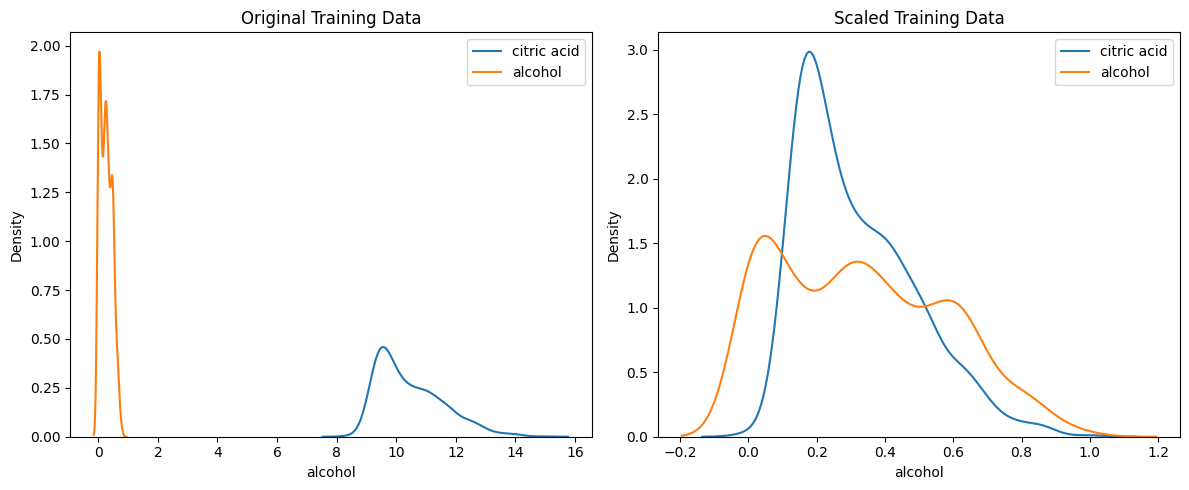

In [28]:
fig, axes = plt.subplots(1,2, figsize=(12, 5))

sns.kdeplot(x_train['alcohol'], ax=axes[0])
sns.kdeplot(x_train['citric acid'], ax=axes[0])
axes[0].legend(['citric acid', 'alcohol'])


sns.kdeplot(scaled_x_train['alcohol'], ax=axes[1])
sns.kdeplot(scaled_x_train['citric acid'], ax=axes[1])
axes[1].legend(['citric acid', 'alcohol'])

axes[1].set_title('Scaled Training Data')
axes[0].set_title('Original Training Data')
plt.tight_layout()
plt.show()

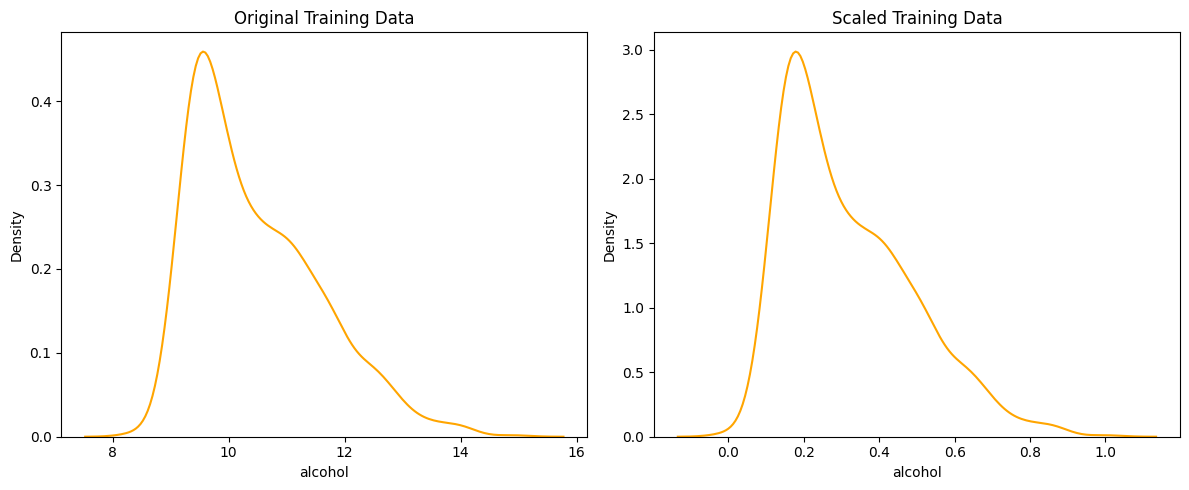

In [30]:
fig, axes = plt.subplots(1,2, figsize=(12, 5))

sns.kdeplot(x_train['alcohol'], ax=axes[0], color='orange')


sns.kdeplot(scaled_x_train['alcohol'], ax=axes[1], color='orange')


axes[1].set_title('Scaled Training Data')
axes[0].set_title('Original Training Data')
plt.tight_layout()
plt.show()

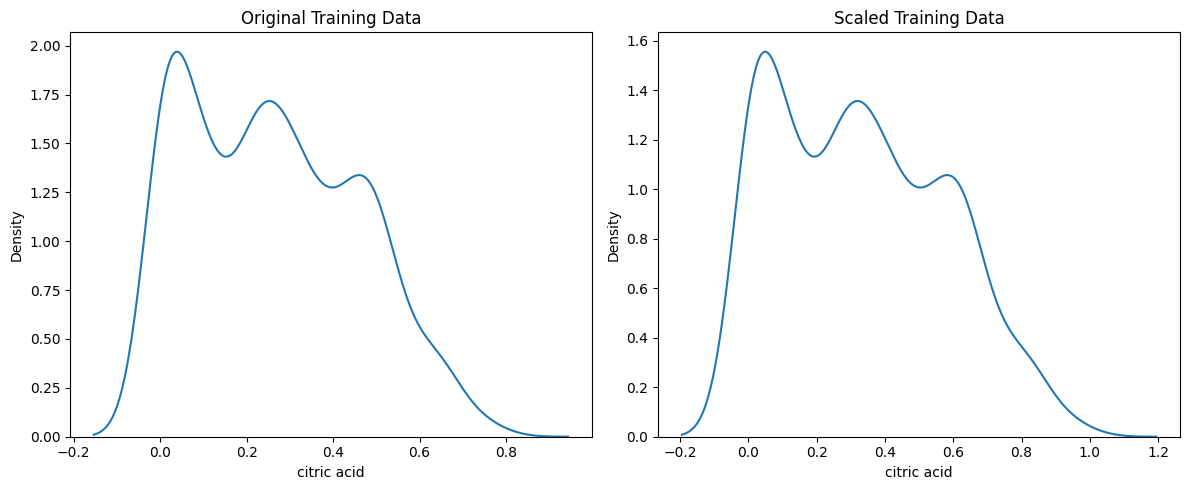

In [18]:
fig, axes = plt.subplots(1,2, figsize=(12, 5))


sns.kdeplot(x_train['citric acid'], ax=axes[0])


sns.kdeplot(scaled_x_train['citric acid'], ax=axes[1])

axes[1].set_title('Scaled Training Data')
axes[0].set_title('Original Training Data')
plt.tight_layout()
plt.show()